In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import kagglehub

In [ ]:
# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

100%|██████████| 1.55k/1.55k [00:00<00:00, 2.22MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1


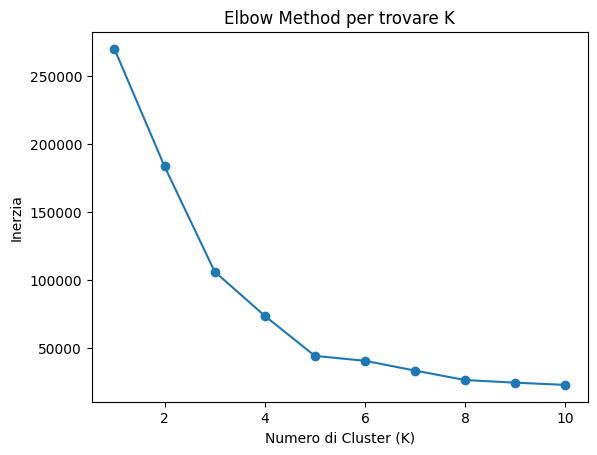

In [ ]:


# 1. Carichiamo i dati (assumiamo di avere il CSV 'Mall_Customers.csv')
df = pd.read_csv(path + "/Mall_Customers.csv")

# Prendiamo solo le colonne che ci interessano per il Business
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

# 2. ELBOW METHOD: Troviamo il numero ideale di Cluster (K)
wcss = []  # Within-Cluster Sum of Squares (Inerzia)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Grafico del Gomito (Elbow)
plt.plot(range(1, 11), wcss, marker="o")
plt.title("Elbow Method per trovare K")
plt.xlabel("Numero di Cluster (K)")
plt.ylabel("Inerzia")
plt.show()

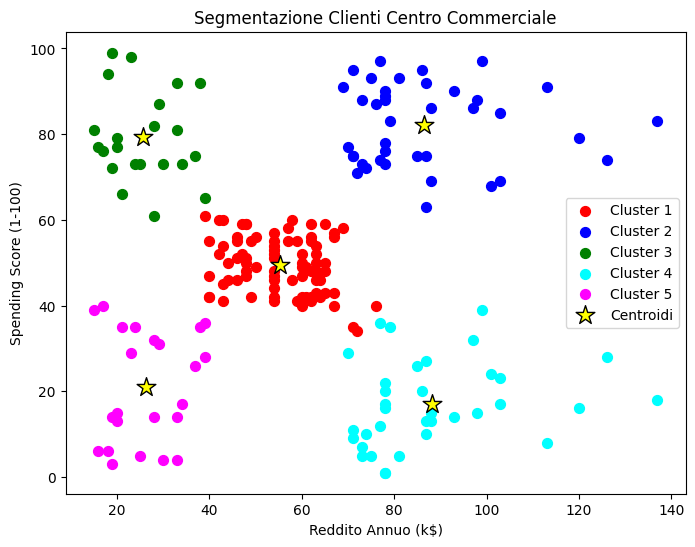

In [ ]:
# 3. Fit di K-Means con K = 5
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)

# 4. Visualizzazione finale dei Cluster + Centroidi
plt.figure(figsize=(8, 6))
colors = ["red", "blue", "green", "cyan", "magenta"]

for i in range(5):
    plt.scatter(
        X[y_kmeans == i, 0],
        X[y_kmeans == i, 1],
        s=50,
        c=colors[i],
        label=f"Cluster {i+1}",
    )

# Disegniamo i Centroidi (i centri dei gruppi)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    c="yellow",
    edgecolors="black",
    marker="*",
    label="Centroidi",
)

plt.title("Segmentazione Clienti Centro Commerciale")
plt.xlabel("Reddito Annuo (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()